# Data Science Final Project Walkthrough

This notebook is the interactive walkthrough version of the project.  
The main Python script (`src/final_project_analysis.py`) is still the reproducible pipeline, but this notebook shows the data, plots, model results, and interpretation step by step.

Run this notebook from top to bottom in VSCode using the project `.venv` kernel.

## 1. Setup

This cell finds the project root, imports the analysis script, and sets up display helpers.

In [37]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown

# Find project root whether this notebook is opened from notebooks/ or from the repo root.
current = Path.cwd()
if (current / "src" / "final_project_analysis.py").exists():
    PROJECT_ROOT = current
elif (current.parent / "src" / "final_project_analysis.py").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find src/final_project_analysis.py. Open this notebook from the project repo.")

SRC_DIR = PROJECT_ROOT / "src"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
DATA_PATH = PROJECT_ROOT / "data" / "imdb_movies.csv"

sys.path.insert(0, str(SRC_DIR))

import final_project_analysis as fpa

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

def show_csv(filename, n=10):
    path = OUTPUT_DIR / filename
    if not path.exists():
        print(f"{filename} does not exist yet.")
        return None
    df_out = pd.read_csv(path)
    display(df_out.head(n))
    return df_out

def show_figure(filename):
    path = FIGURE_DIR / filename
    if not path.exists():
        print(f"{filename} does not exist yet.")
        return
    display(Image(filename=str(path)))

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)

Project root: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject
Data path: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject\data\imdb_movies.csv


## 2. Load the raw dataset

In [38]:
raw_df = pd.read_csv(DATA_PATH)

print("Raw dataset shape:", raw_df.shape)
display(raw_df.head(10))
display(raw_df.info())

Raw dataset shape: (10178, 12)


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US
5,Cocaine Bear,02/23/2023,66.0,"Thriller, Comedy, Crime","Inspired by a true story, an oddball group of ...","Keri Russell, Sari, Alden Ehrenreich, Eddie, O...",Cocaine Bear,Released,English,35000000.0,8.000000e+07,AU
6,John Wick: Chapter 4,03/23/2023,80.0,"Action, Thriller, Crime","With the price on his head ever increasing, Jo...","Keanu Reeves, John Wick, Donnie Yen, Caine, Bi...",John Wick: Chapter 4,Released,English,100000000.0,3.513494e+08,AU
7,Puss in Boots: The Last Wish,12/26/2022,83.0,"Animation, Family, Fantasy, Adventure, Comedy",Puss in Boots discovers that his passion for a...,"Antonio Banderas, Puss in Boots (voice), Salma...",Puss in Boots: The Last Wish,Released,English,90000000.0,4.834806e+08,AU
8,Attack on Titan,09/30/2022,59.0,"Action, Science Fiction","As viable water is depleted on Earth, a missio...","Paul Bianchi, Computer (voice), Erin Coker, Al...",Attack on Titan,Released,English,71000000.0,2.549465e+08,US
9,The Park,03/02/2023,58.0,"Action, Drama, Horror, Science Fiction, Thriller",A dystopian coming-of-age movie focused on thr...,"Chloe Guidry, Ines, Nhedrick Jabier, Bui, Carm...",The Park,Released,English,119200000.0,4.889625e+08,US


<class 'pandas.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  str    
 1   date_x      10178 non-null  str    
 2   score       10178 non-null  float64
 3   genre       10093 non-null  str    
 4   overview    10178 non-null  str    
 5   crew        10122 non-null  str    
 6   orig_title  10178 non-null  str    
 7   status      10178 non-null  str    
 8   orig_lang   10178 non-null  str    
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  str    
dtypes: float64(3), str(9)
memory usage: 954.3 KB


None

## 3. Clean the data and create engineered features

The cleaning function:
- renames columns
- parses release dates
- creates `release_year`
- creates `profit`, `roi`, `roi_capped`
- creates log-transformed financial features
- filters to released movies with usable scores/budget/revenue
- groups rare genre/language/country values into `"Other"`
- saves `cleaned_movies.csv` and `data_quality_summary.csv`

In [39]:
fpa.ensure_output_dirs()
df = fpa.load_and_clean_data()

print("Cleaned dataset shape:", df.shape)
display(df.head(50))

important_cols = [
    "title", "score", "budget", "revenue", "profit", "roi", "roi_capped",
    "log_budget", "log_revenue", "log_profit_shifted",
    "release_year", "main_genre", "language", "country"
]
display(df[important_cols].head())


Cleaned dataset shape: (9967, 41)


,title,release_date,score,genre,overview,crew,orig_title,status,language,budget,revenue,country,release_year,main_genre,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science_Fiction,genre_TV_Movie,genre_Thriller,genre_Unknown,genre_War,genre_Western,is_english,profit,roi,roi_capped,log_budget,log_revenue,log_profit_shifted
0,Creed III,2023-03-02,73.0,"Drama,Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,2023,Drama,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.966167e+08,2.621556,2.621556,18.132999,19.419902,20.100795
1,Avatar: The Way of Water,2022-12-15,78.0,"Science Fiction,Adventure,Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,2022,Science Fiction,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1.856795e+09,4.036511,4.036511,19.946737,21.563451,21.510265
2,The Super Mario Bros. Movie,2023-04-05,76.0,"Animation,Adventure,Family,Fantasy,Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,2023,Animation,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,6.244590e+08,6.244590,6.244590,18.420681,20.400936,20.687078
3,Mummies,2023-01-05,70.0,"Animation,Comedy,Family,Adventure,Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,2023,Animation,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,2.190000e+07,1.780488,1.780488,16.325110,17.347736,19.706878
4,Supercell,2023-03-17,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,2023,Action,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2.639420e+08,3.427818,3.427818,18.159316,19.647223,20.218989
5,Cocaine Bear,2023-02-23,66.0,"Thriller,Comedy,Crime","Inspired by a true story, an oddball group of ...","Keri Russell, Sari, Alden Ehrenreich, Eddie, O...",Cocaine Bear,Released,English,35000000.0,8.000000e+07,AU,2023,Thriller,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,4.500000e+07,1.285714,1.285714,17.370859,18.197537,19.768754
6,John Wick: Chapter 4,2023-03-23,80.0,"Action,Thriller,Crime","With the price on his head ever increasing, Jo...","Keanu Reeves, John Wick, Donnie Yen, Caine, Bi...",John Wick: Chapter 4,Released,English,100000000.0,3.513494e+08,AU,2023,Action,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,2.513494e+08,2.513494,2.513494,18.420681,19.677292,20.197918
7,Puss in Boots: The Last Wish,2022-12-26,83.0,"Animation,Family,Fantasy,Adventure,Comedy",Puss in Boots discovers that his passion for a...,"Antonio Banderas, Puss in Boots (voice), Salma...",Puss in Boots: The Last Wish,Released,English,90000000.0,4.834806e+08,AU,2022,Animation,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,3.934806e+08,4.372006,4.372006,18.315320,19.996522,20.413312
8,Attack on Titan,2022-09-30,59.0,"Action,Science Fiction","As viable water is depleted on Earth, a missio...","Paul Bianchi, Computer (voice), Erin Coker, Al...",Attack on Titan,Released,English,71000000.0,2.549465e+08,US,2022,Action,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1.839465e+08,2.590796,2.590796,18.078190,19.356564,20.076900
9,The Park,2023-03-02,58.0,"Action,Drama,Horror,Science Fiction,Thriller",A dystopian coming-of-age movie focused on thr...,"Chloe Guidry, Ines, Nhedrick Jabier, Bui, Carm...",The Park,Released,English,119200000.0,4.889625e+08,US,2023,Action,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,3.697625e+08,3.102034,3.102034,18.596313,20.007796,20.380441


,title,score,budget,revenue,profit,roi,roi_capped,log_budget,log_revenue,log_profit_shifted,release_year,main_genre,language,country
0,Creed III,73.0,75000000.0,2.716167e+08,1.966167e+08,2.621556,2.621556,18.132999,19.419902,20.100795,2023,Drama,English,AU
1,Avatar: The Way of Water,78.0,460000000.0,2.316795e+09,1.856795e+09,4.036511,4.036511,19.946737,21.563451,21.510265,2022,Science Fiction,English,AU
2,The Super Mario Bros. Movie,76.0,100000000.0,7.244590e+08,6.244590e+08,6.244590,6.244590,18.420681,20.400936,20.687078,2023,Animation,English,AU
3,Mummies,70.0,12300000.0,3.420000e+07,2.190000e+07,1.780488,1.780488,16.325110,17.347736,19.706878,2023,Animation,"Spanish, Castilian",AU
4,Supercell,61.0,77000000.0,3.409420e+08,2.639420e+08,3.427818,3.427818,18.159316,19.647223,20.218989,2023,Action,English,US


### Data quality summary

This summarizes how much data was removed and checks missing/zero values.

In [40]:
data_quality = show_csv("data_quality_summary.csv")

,original_rows,cleaned_rows,rows_removed,percent_rows_removed,missing_genre_count,missing_genre_rate,missing_crew_count,missing_crew_rate,zero_budget_count,zero_budget_rate,zero_revenue_count,zero_revenue_rate,score_min,score_max,score_mean,score_median
0,10178,9967,211,0.0207,85,0.0084,56,0.0055,0,0.0,73,0.0072,0.0,100.0,63.497052,65.0


## 4. Exploratory Data Analysis

The script generates EDA figures into `outputs/figures/`.  
This notebook displays those figures inline so the group can discuss them.

### hist_score.png

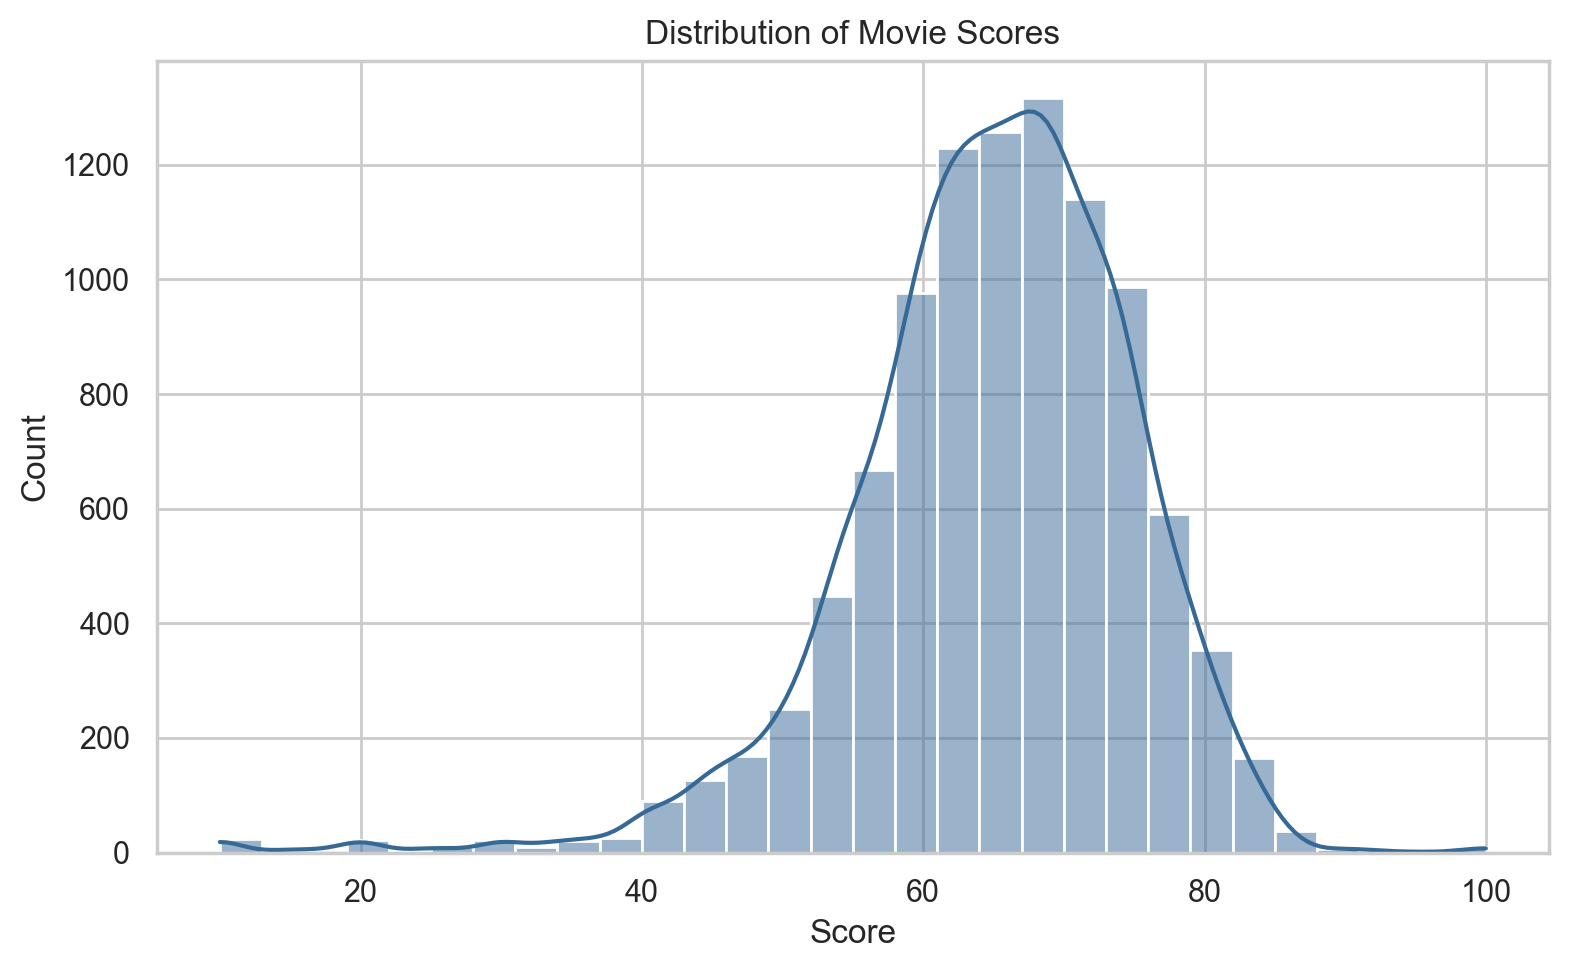

### hist_budget.png

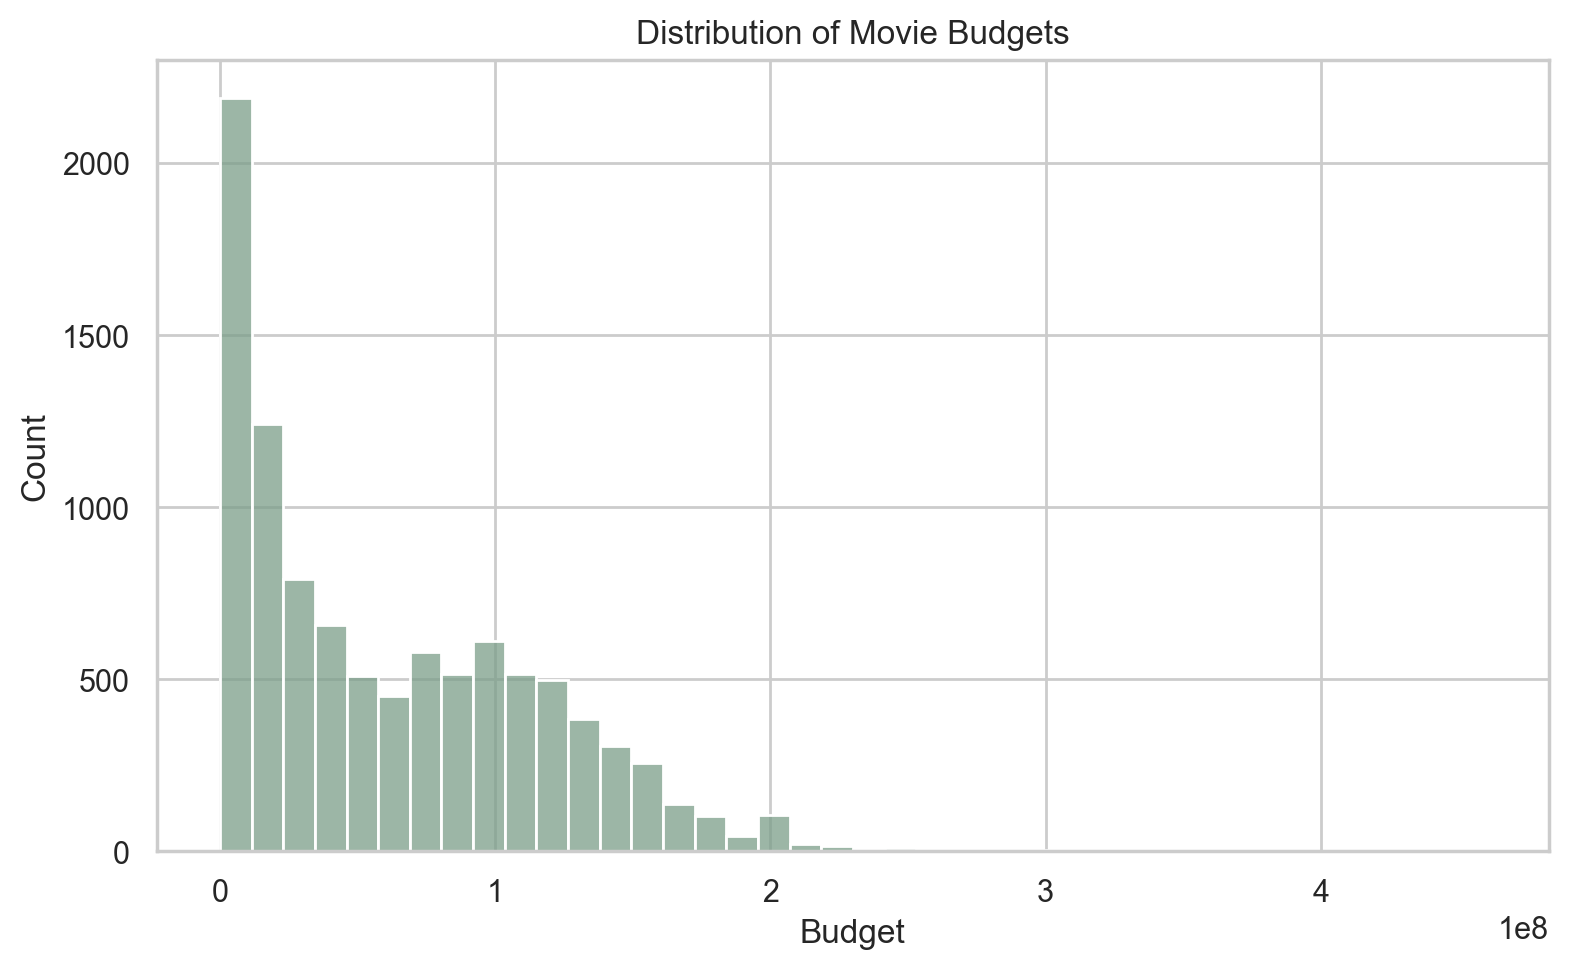

### hist_revenue.png

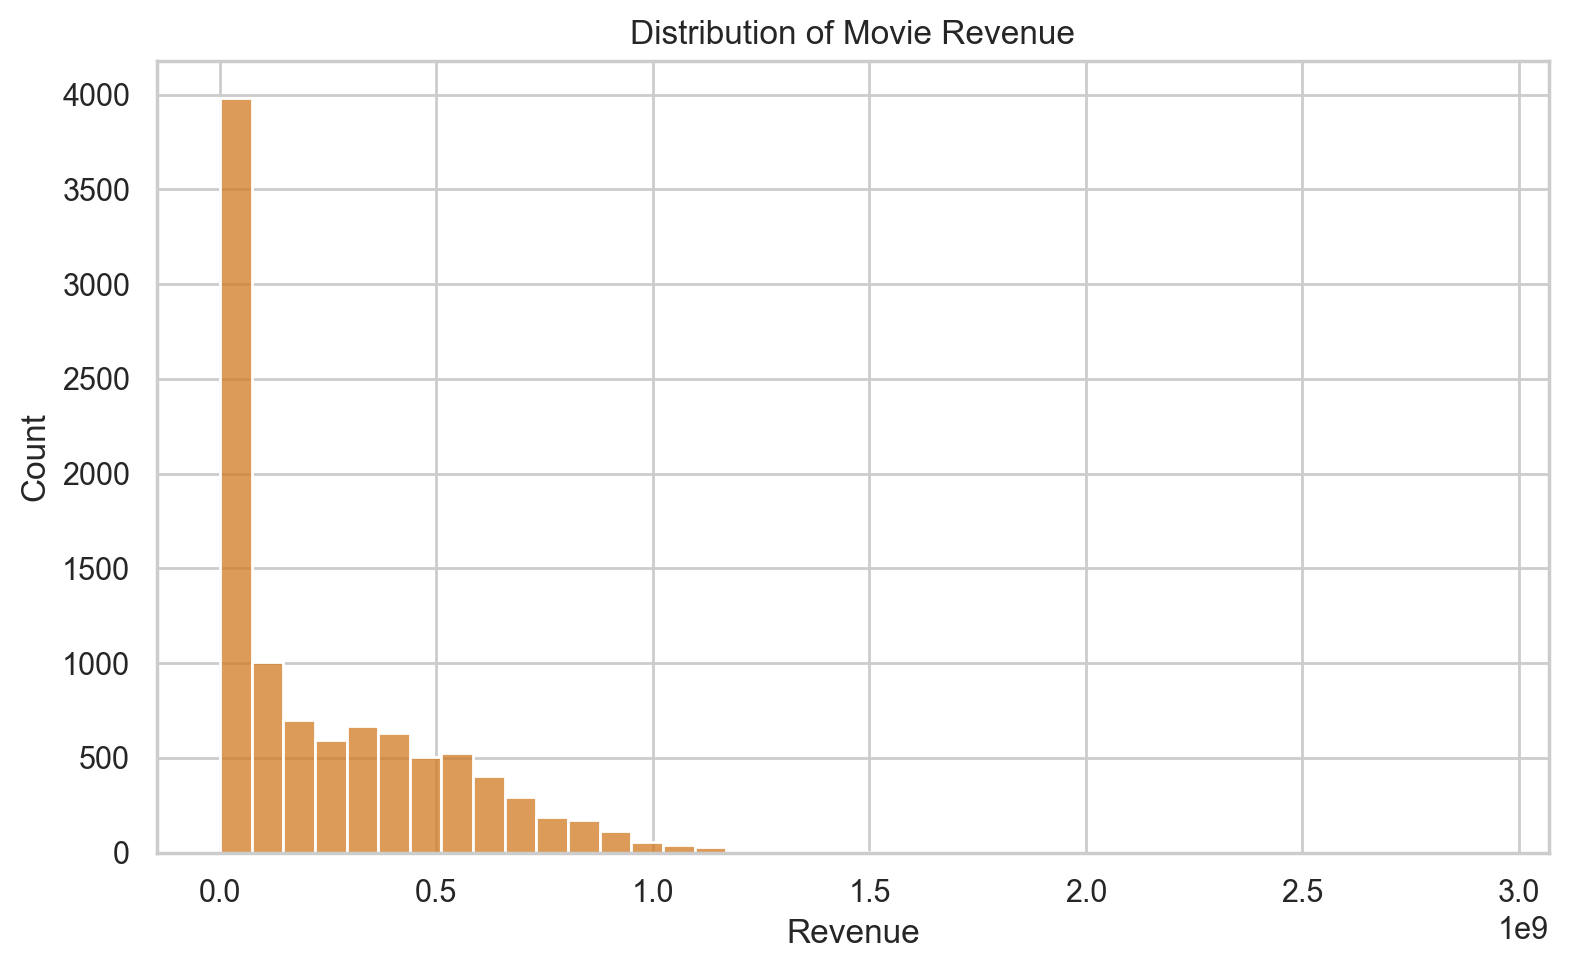

### hist_log_budget.png

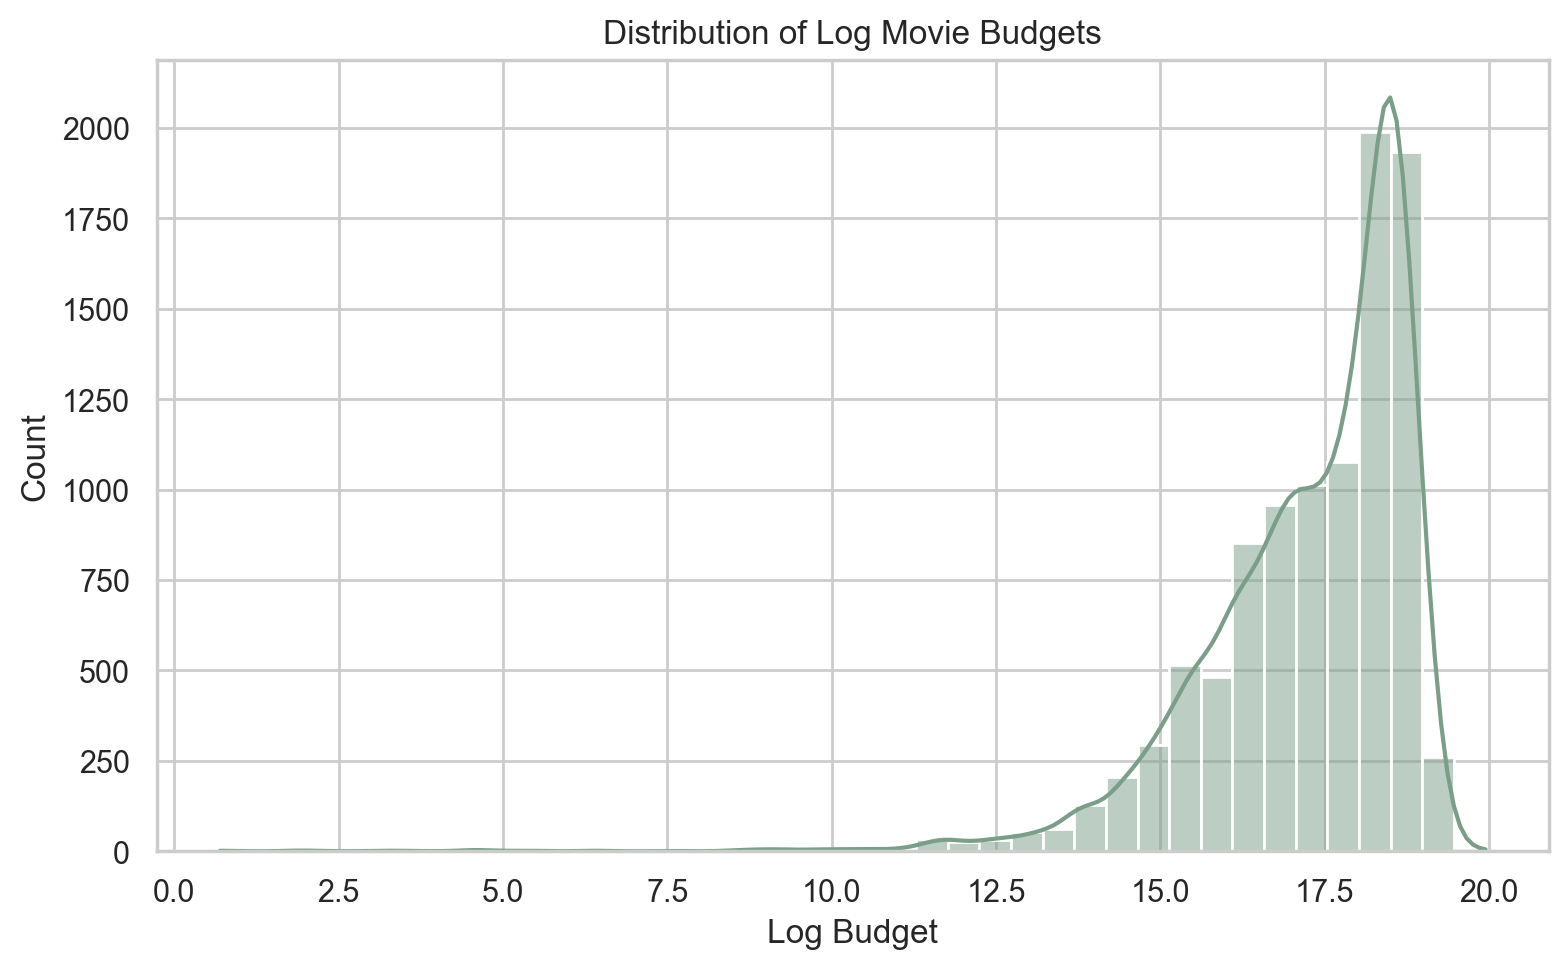

### hist_log_revenue.png

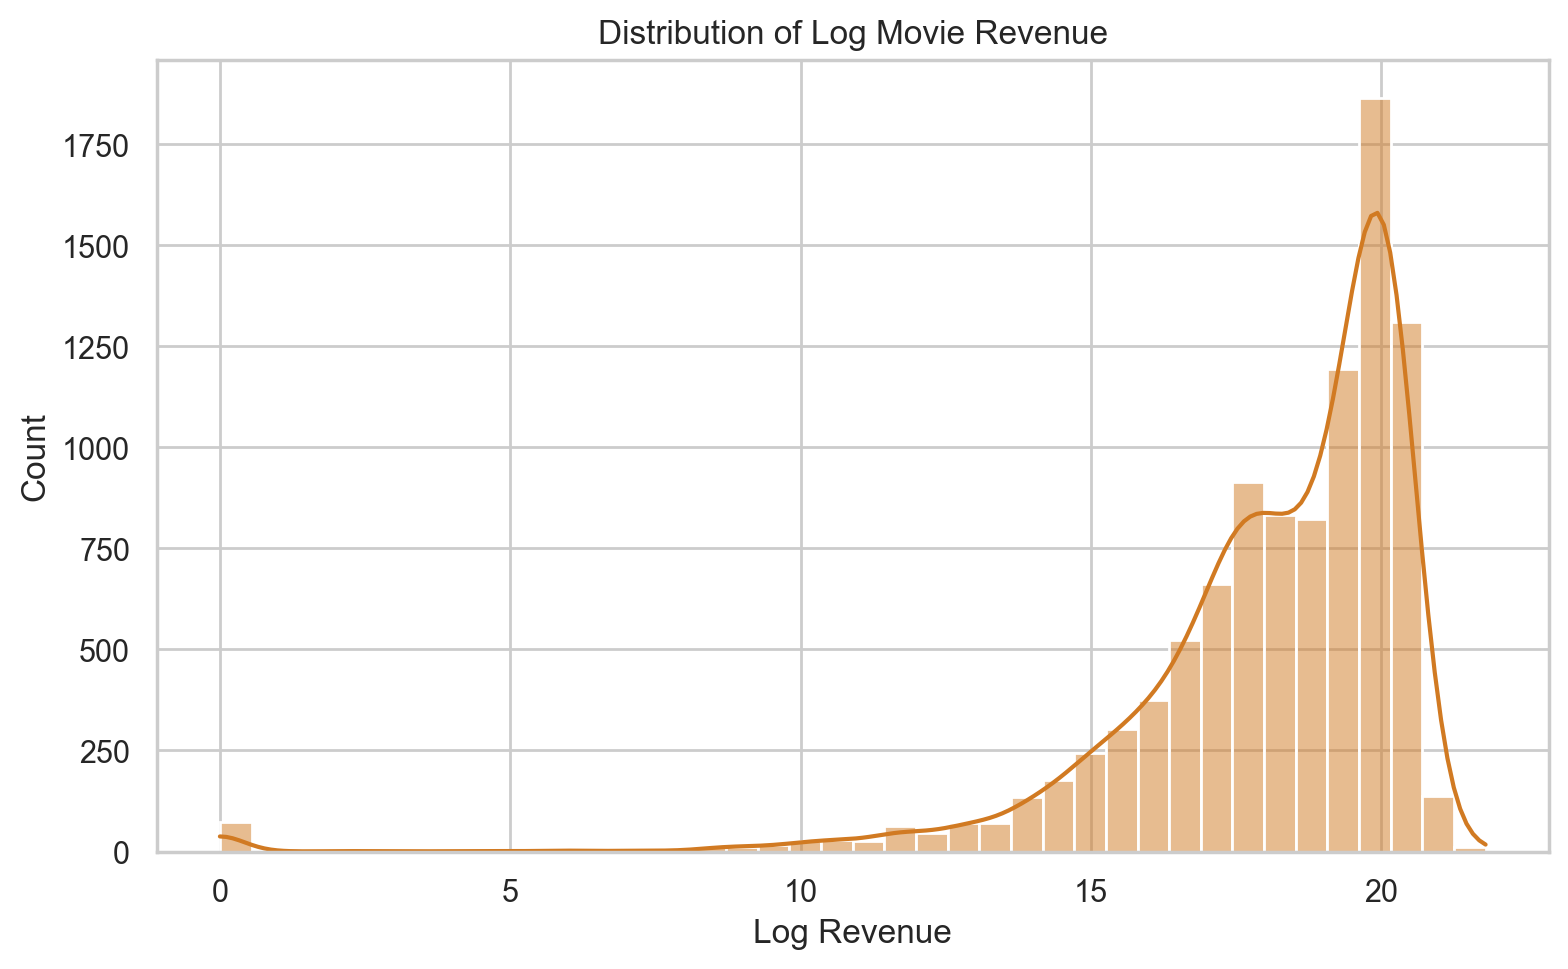

### scatter_budget_score.png

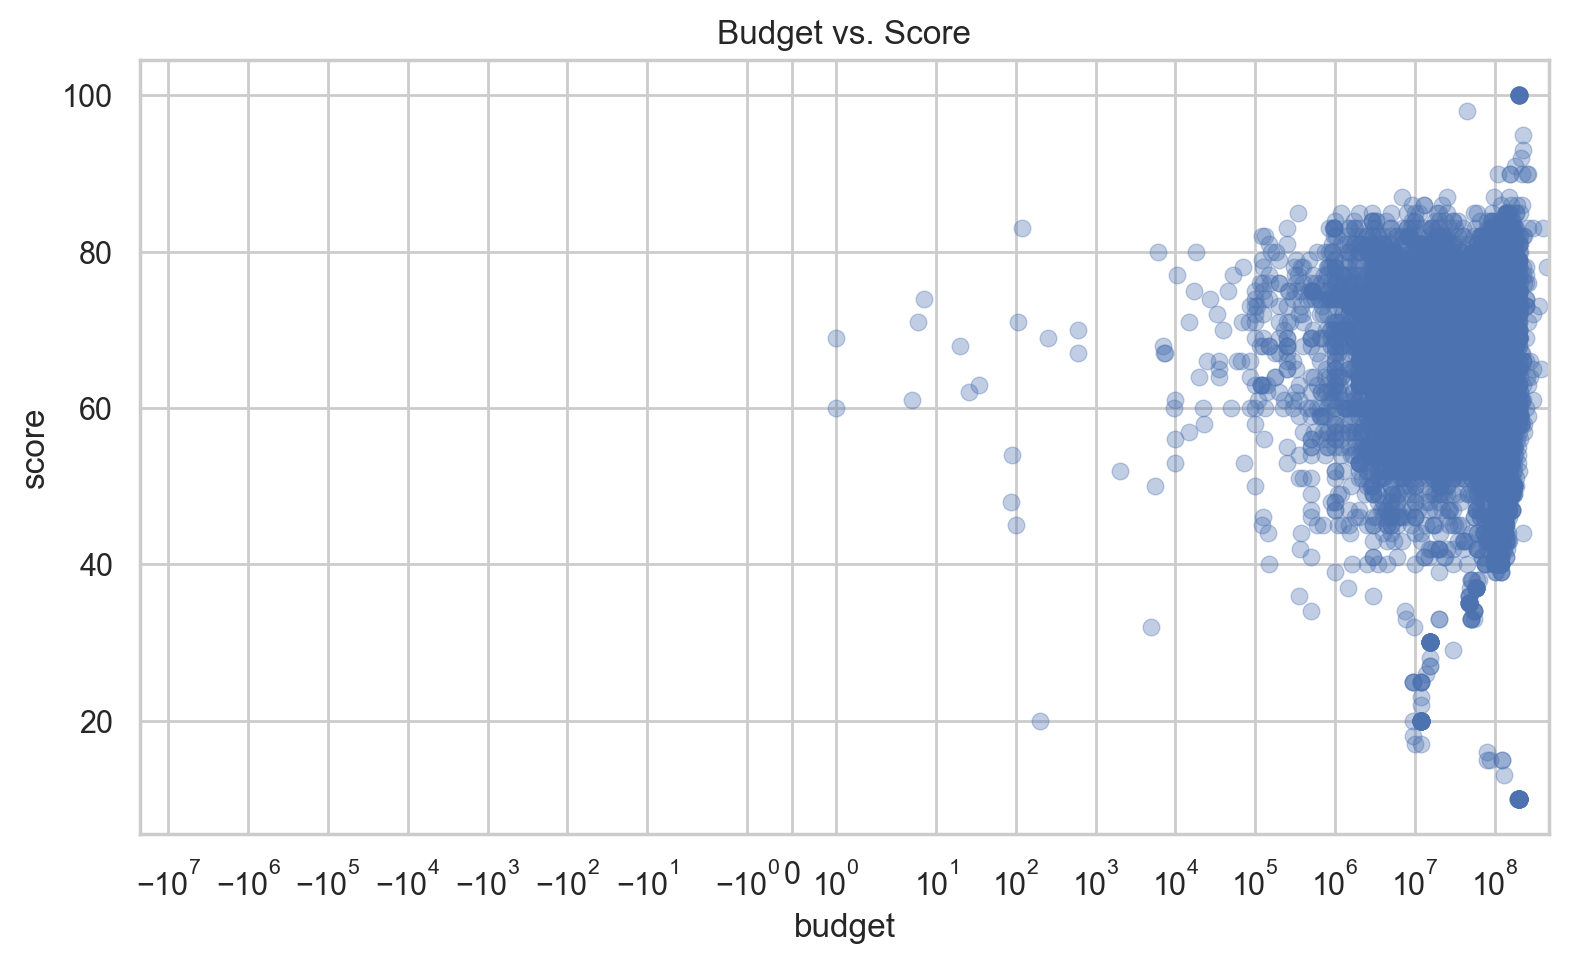

### scatter_revenue_score.png

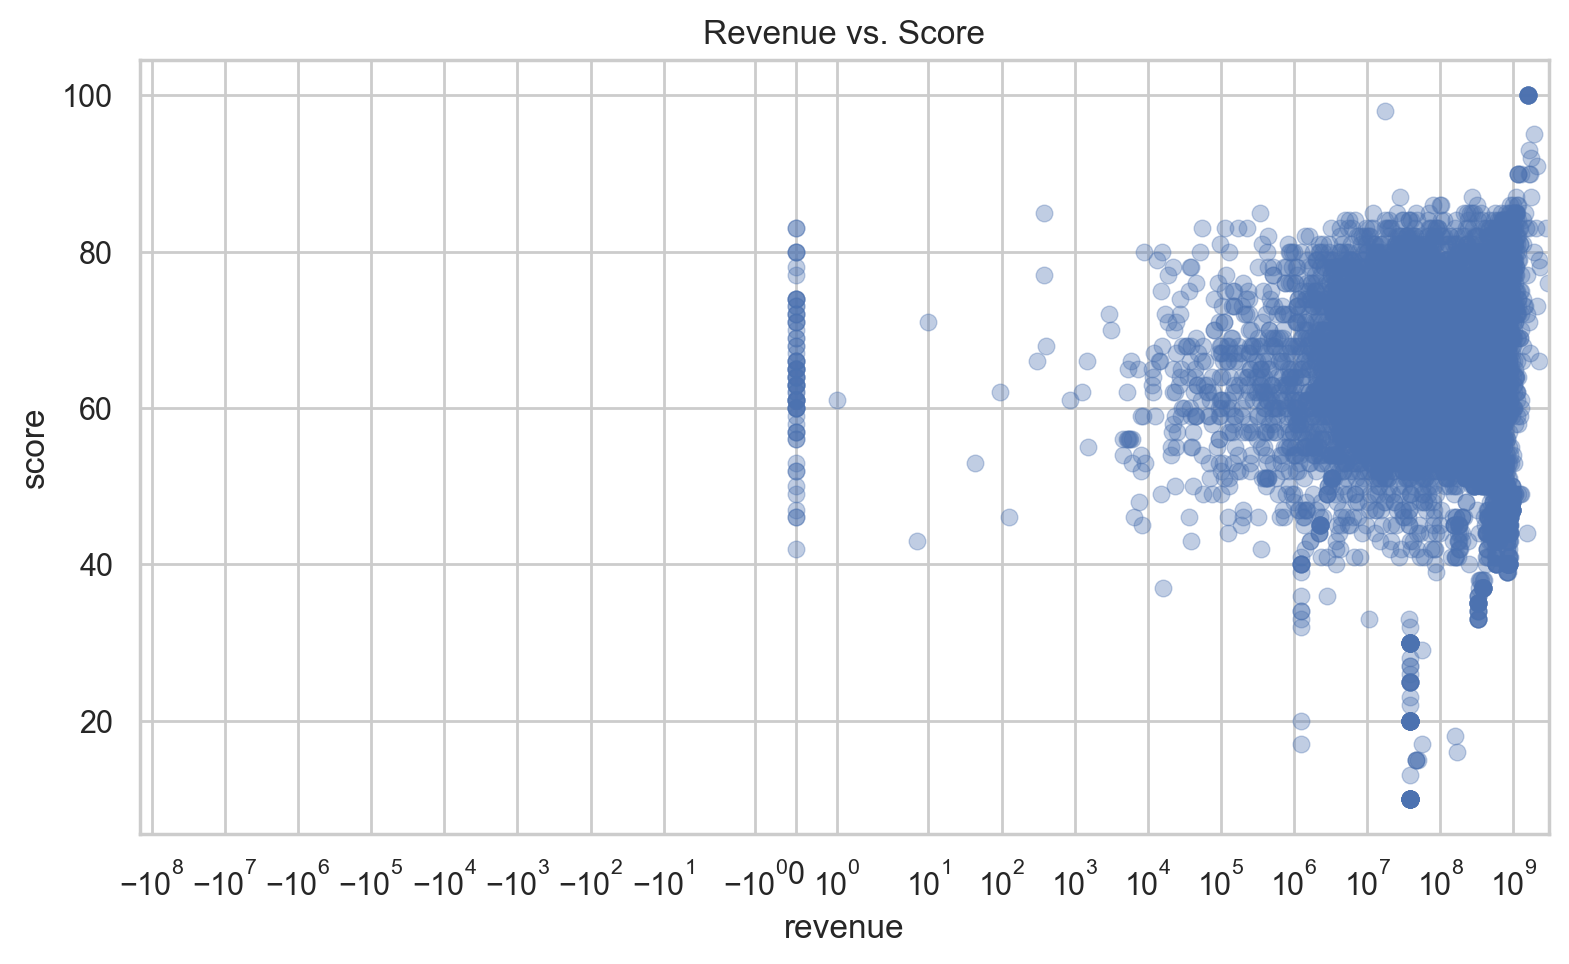

### box_score_by_genre.png

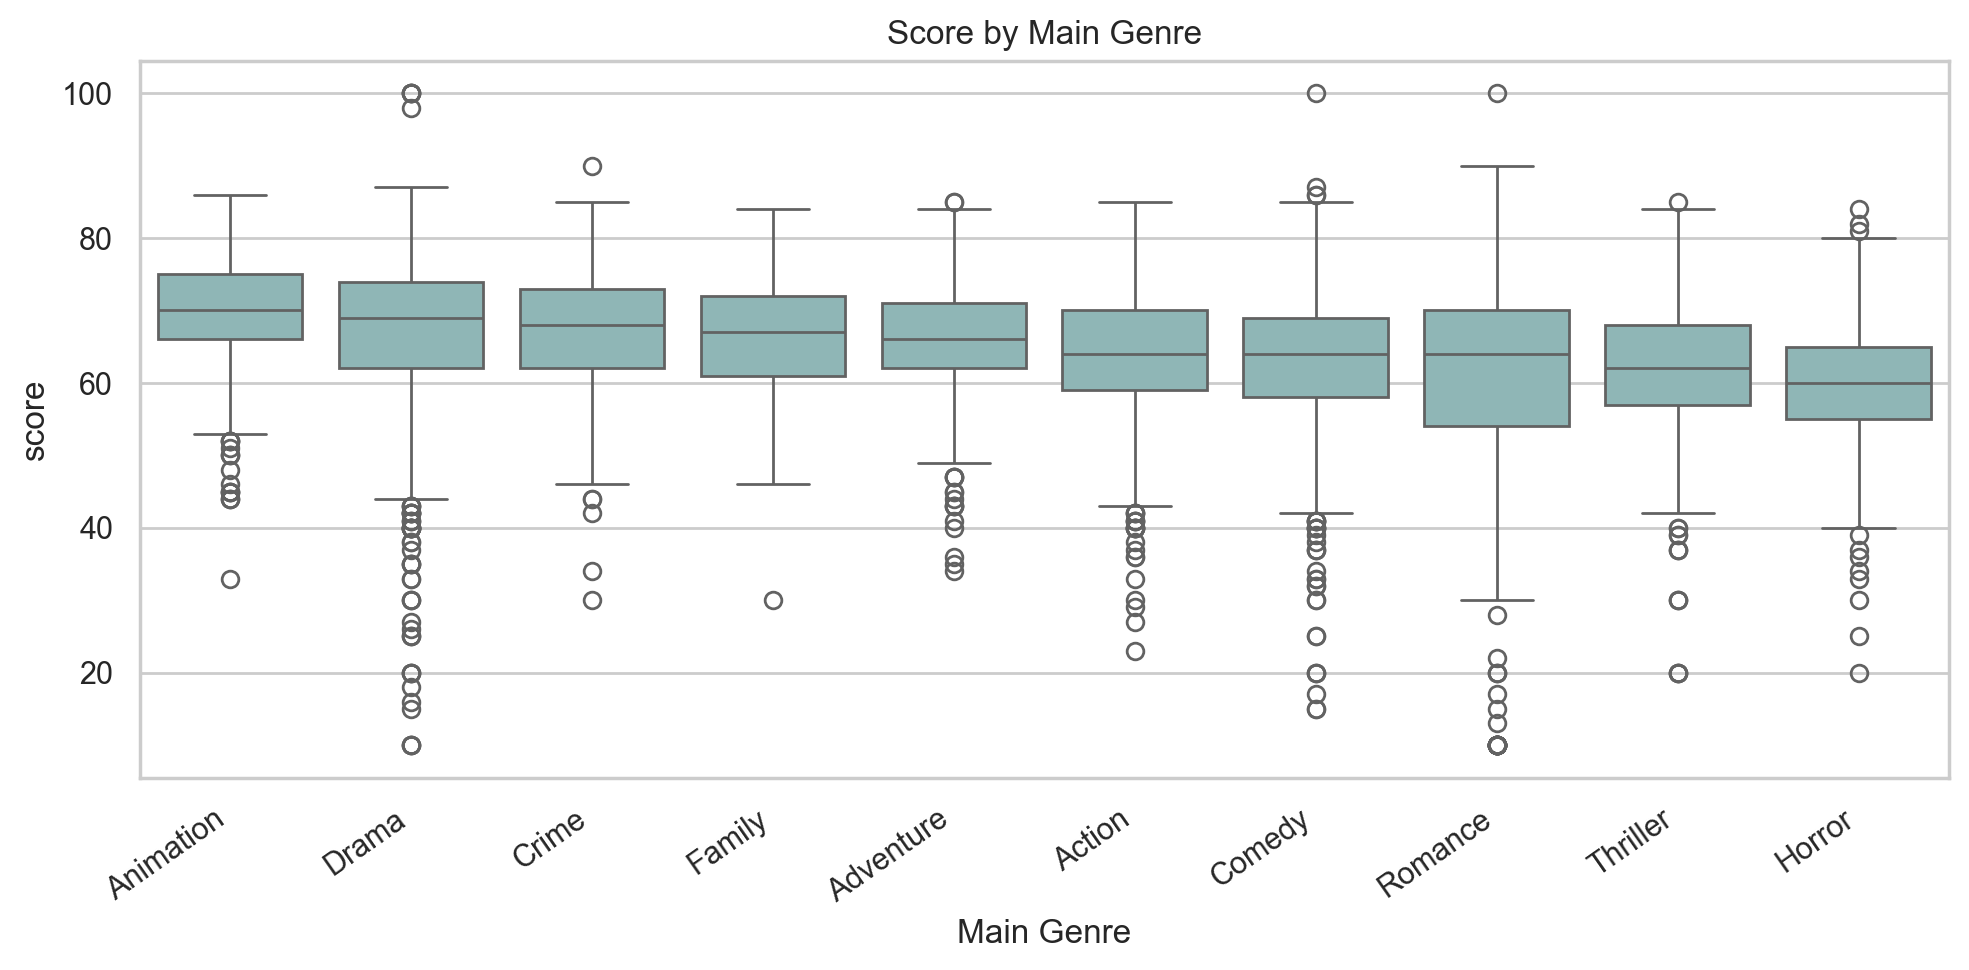

### box_score_by_language.png

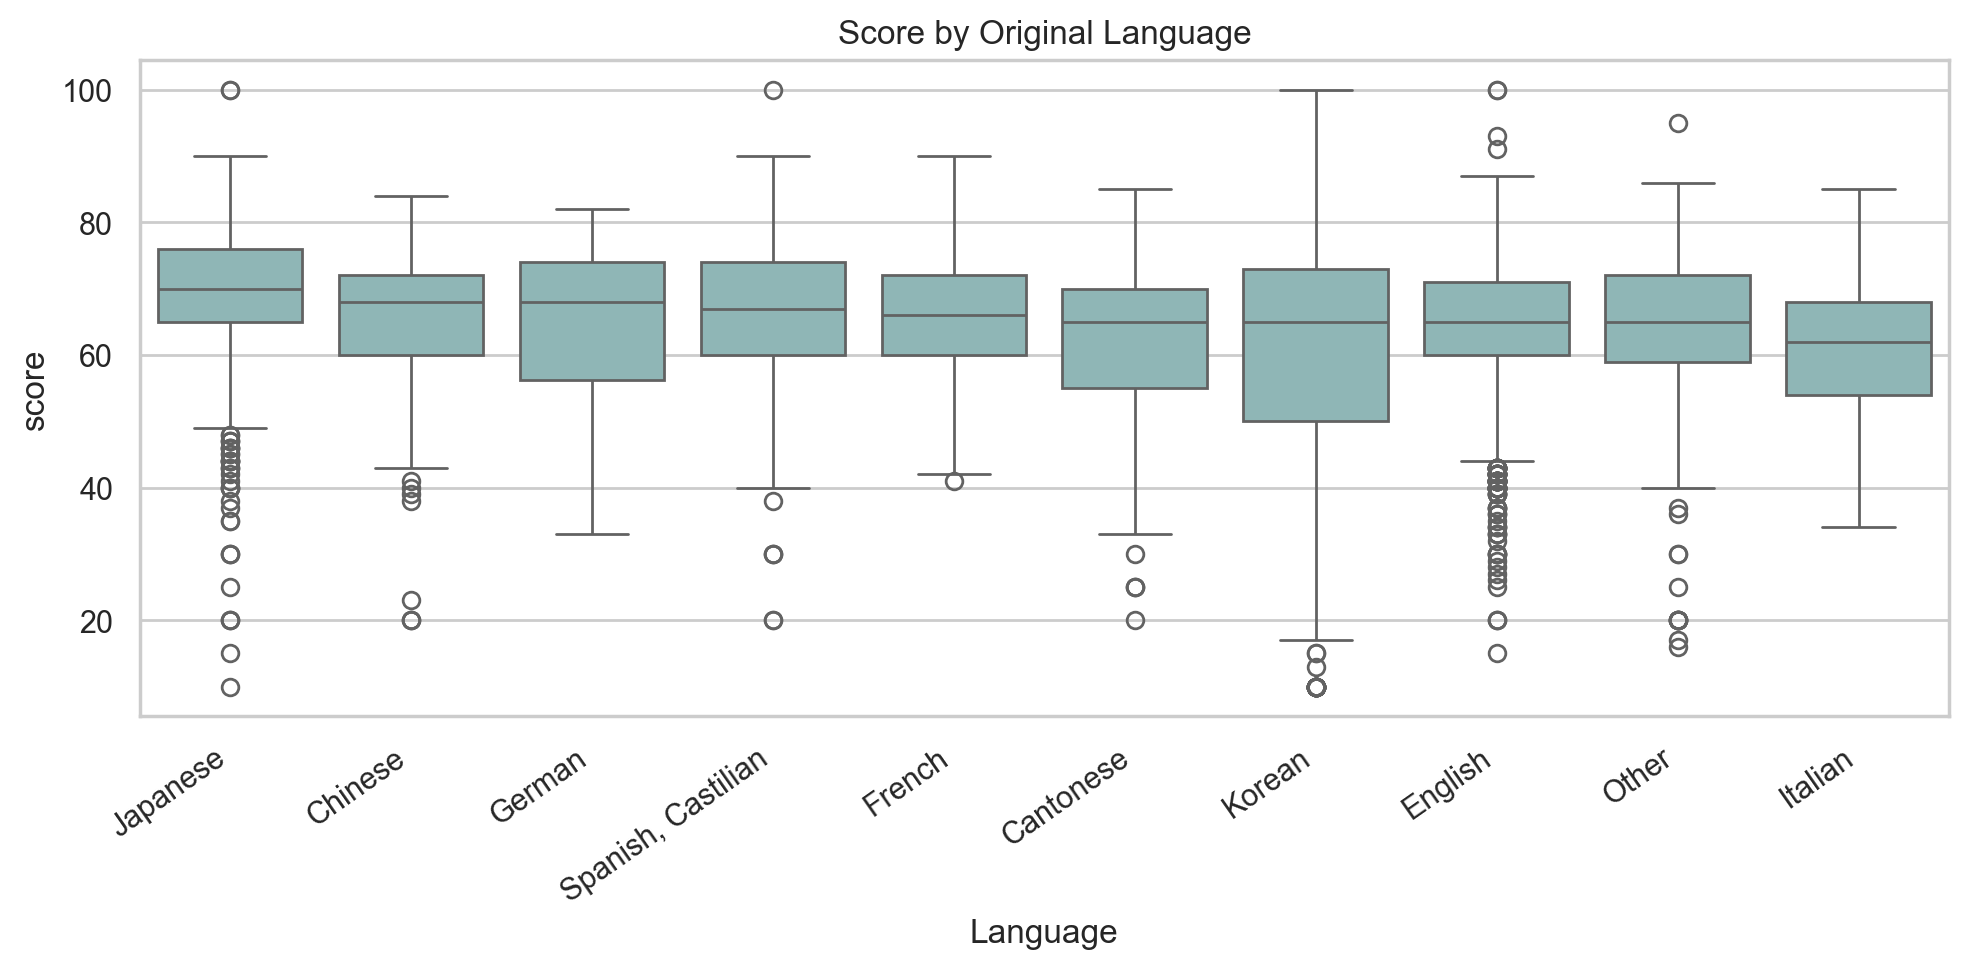

### box_score_by_country.png

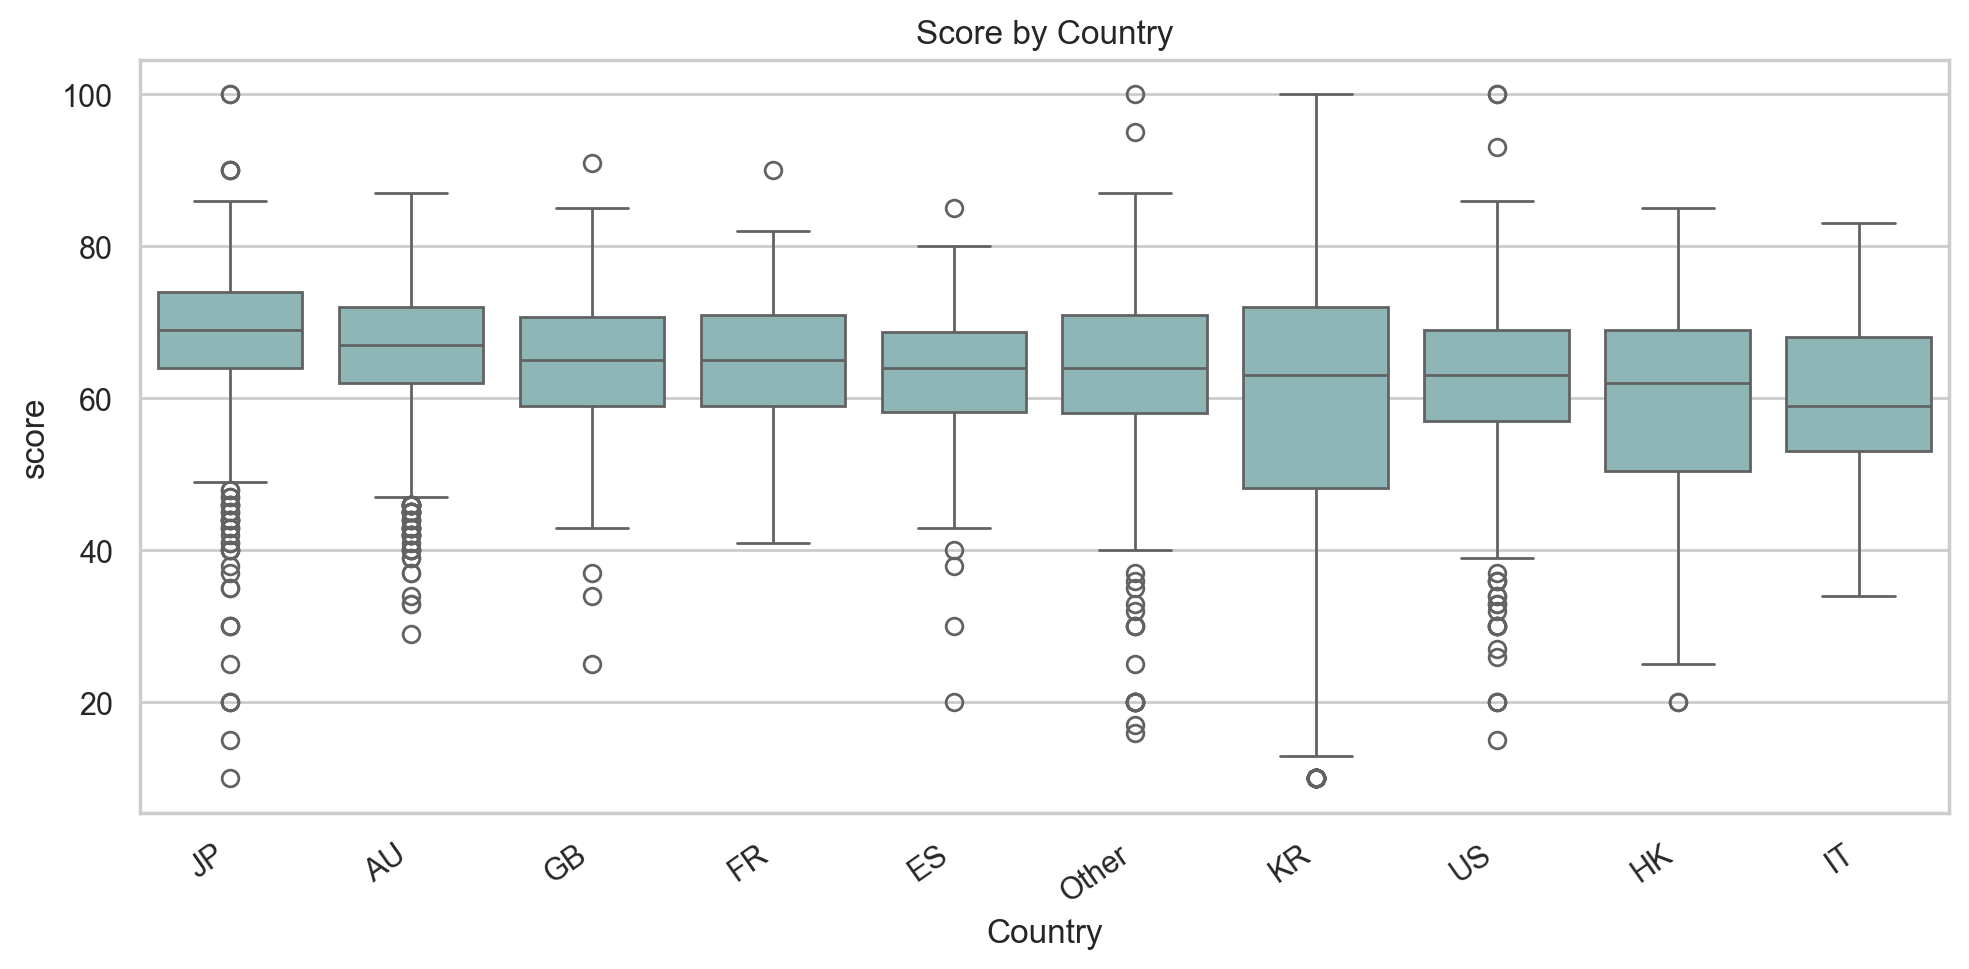

### correlation_heatmap.png

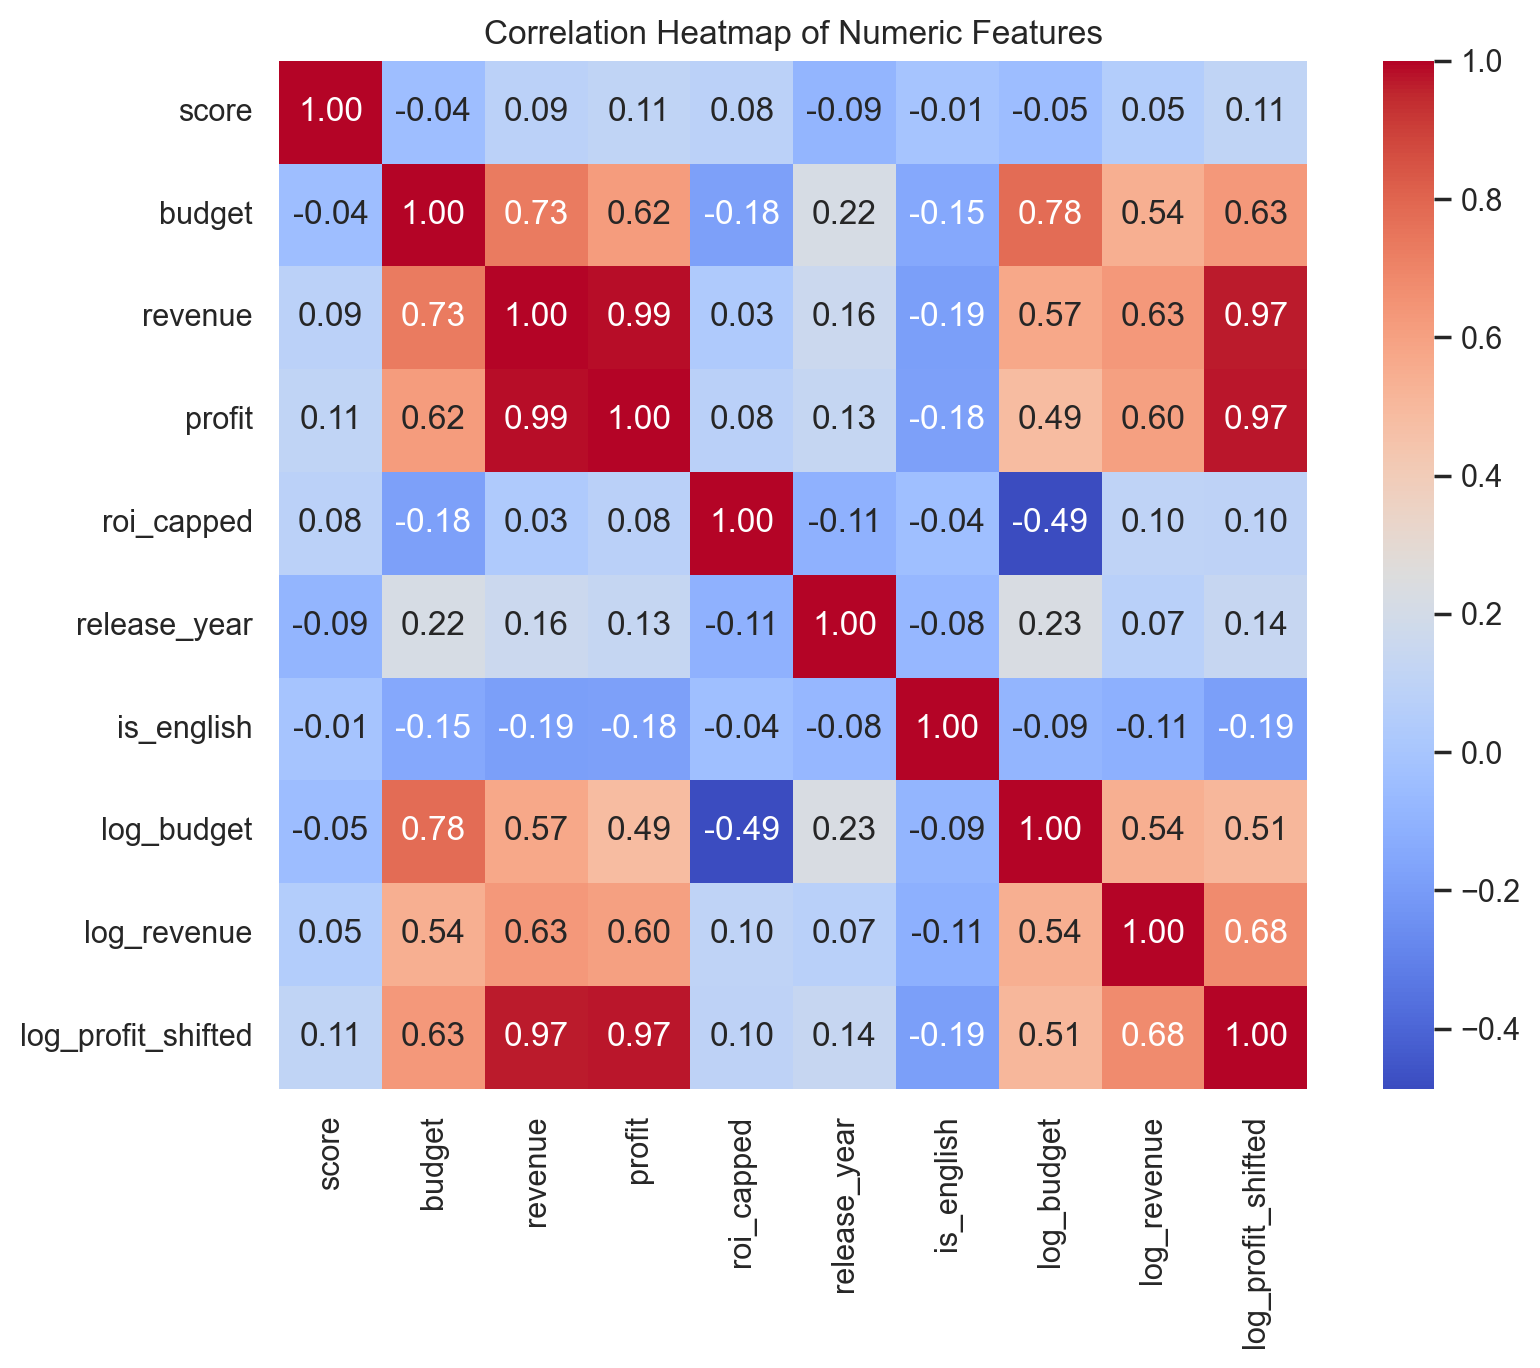

In [41]:
fpa.make_eda_visualizations(df)

eda_figures = [
    "hist_score.png",
    "hist_budget.png",
    "hist_revenue.png",
    "hist_log_budget.png",
    "hist_log_revenue.png",
    "scatter_budget_score.png",
    "scatter_revenue_score.png",
    "box_score_by_genre.png",
    "box_score_by_language.png",
    "box_score_by_country.png",
    "correlation_heatmap.png",
]

for fig in eda_figures:
    display(Markdown(f"### {fig}"))
    show_figure(fig)

## 5. Regression models

The regression task predicts the continuous movie `score`.

We compare:
1. **Mean score baseline** — always predicts the training-set average score.
2. **Baseline linear regression** — uses only raw `budget` and `revenue`.
3. **Improved linear regression** — uses engineered financial features and categorical metadata.

In [42]:
mean_baseline = fpa.mean_score_baseline(df)
baseline = fpa.regression_baseline(df)
improved, improved_model = fpa.improved_regression(df)

regression_results = pd.DataFrame([mean_baseline, baseline, improved])
display(regression_results)

,model,rmse,mae,r2
0,Mean score baseline,10.329464,7.717587,-0.000517
1,Baseline linear regression,10.121755,7.547621,0.039316
2,Improved linear regression,8.949143,6.546600,0.249014


### Regression coefficients

The improved regression model is linear, so we can inspect coefficients.  
Large coefficients should be interpreted as associations in this dataset, not causal effects.

In [43]:
fpa.save_regression_coefficients(improved_model)

coef_df = pd.read_csv(OUTPUT_DIR / "top_regression_coefficients.csv")
display(coef_df)

plt.figure(figsize=(10, 6))
plot_df = coef_df.sort_values("absolute_coefficient", ascending=True)
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.title("Top Improved Regression Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

,feature,coefficient,absolute_coefficient
0,categorical__country_AU,5.838447,5.838447
1,categorical__country_MX,5.801311,5.801311
2,categorical__country_IT,-5.137927,5.137927
3,categorical__country_HK,-4.995088,4.995088
4,categorical__country_KR,-4.339592,4.339592
5,categorical__country_GB,3.488387,3.488387
6,categorical__country_DE,-3.355280,3.355280
7,numeric__log_profit_shifted,2.119733,2.119733
8,numeric__genre_Animation,2.023821,2.023821
9,numeric__genre_Drama,1.707596,1.707596


C:\Users\craig\AppData\Local\Temp\ipykernel_71588\3363818183.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. Classification models

The classification task converts movie scores into three quantile-based groups:
- `low`
- `medium`
- `high`

This avoids the earlier issue where fixed cutoffs made one class dominate the dataset.

In [44]:
classification_baseline = fpa.classification_majority_baseline(df)
classification = fpa.classification_model(df)

classification_results = pd.DataFrame([classification_baseline, classification])
display(classification_results)

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,low_rate,medium_rate,high_rate
0,Majority class baseline: score category,0.367603,0.333333,0.122534,0.333333,0.179196,0.135132,0.367603,0.197619,0.367713,0.301696,0.330591
1,Logistic regression classification: score quan...,0.524574,0.515569,0.508260,0.515569,0.510077,0.514072,0.524574,0.517586,0.367713,0.301696,0.330591


### Score category cutoffs

These are the actual score ranges used for the low/medium/high quantile categories.

In [45]:
cutoffs = show_csv("score_category_cutoffs.csv")

,category,score_lower_bound,score_upper_bound
0,low,10.0,62.0
1,medium,62.0,69.0
2,high,69.0,100.0


### Confusion matrix and error analysis

The confusion matrix shows which categories the model predicts correctly or confuses.

### Confusion matrix table

,Actual,high,low,medium
0,high,417,109,133
1,low,122,441,170
2,medium,188,226,188


### Confusion matrix plot

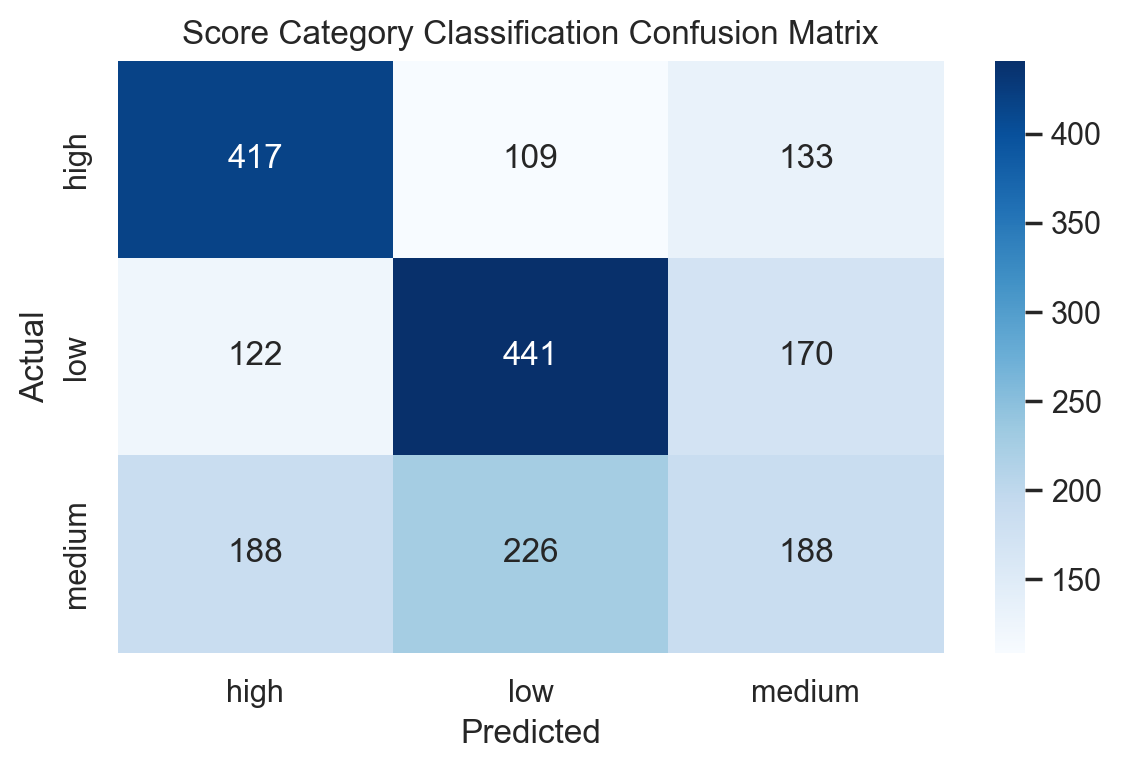

### Per-category error analysis

,score_category,actual_count,predicted_count,correct_predictions,recall,precision
0,low,733,776,441,0.6016,0.5683
1,medium,602,491,188,0.3123,0.3829
2,high,659,727,417,0.6328,0.5736


In [46]:
display(Markdown("### Confusion matrix table"))
confusion = show_csv("score_category_confusion_matrix.csv")

display(Markdown("### Confusion matrix plot"))
show_figure("score_category_confusion_matrix.png")

display(Markdown("### Per-category error analysis"))
error_analysis = show_csv("classification_error_analysis.csv")

## 7. K-Means clustering and PCA

The clustering task is unsupervised.  
Importantly, `score` is **not** used as a clustering input. We cluster movies using metadata and financial features, then compare average score afterward.

The PCA plot is used only to visualize the clusters in two dimensions.

### K-Means elbow plot

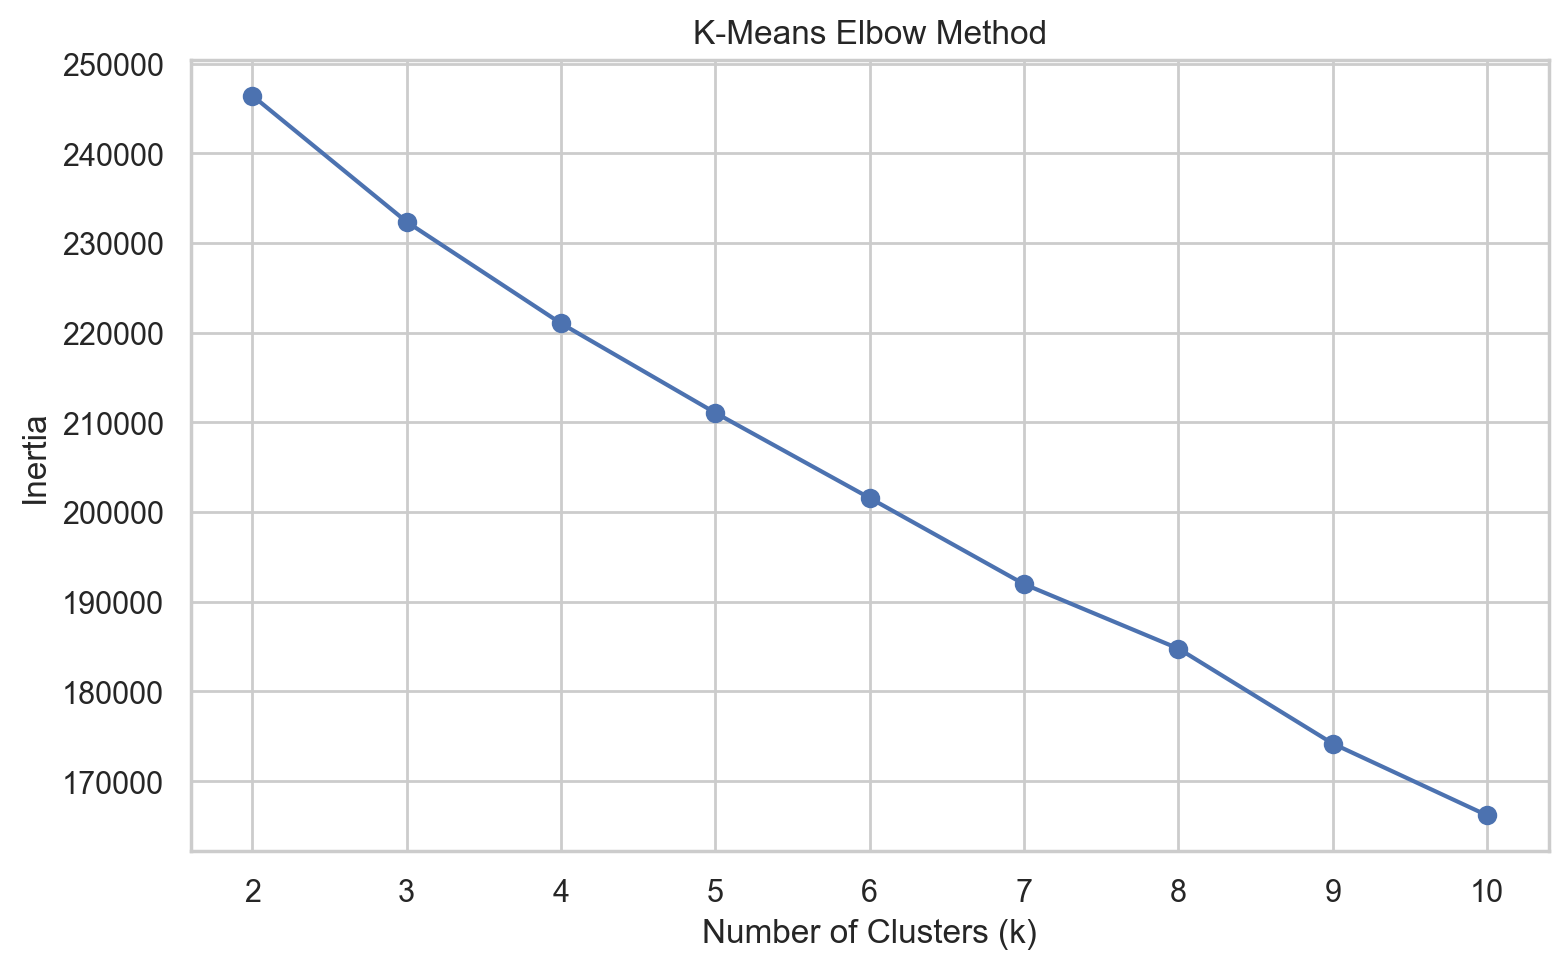

### PCA visualization of clusters

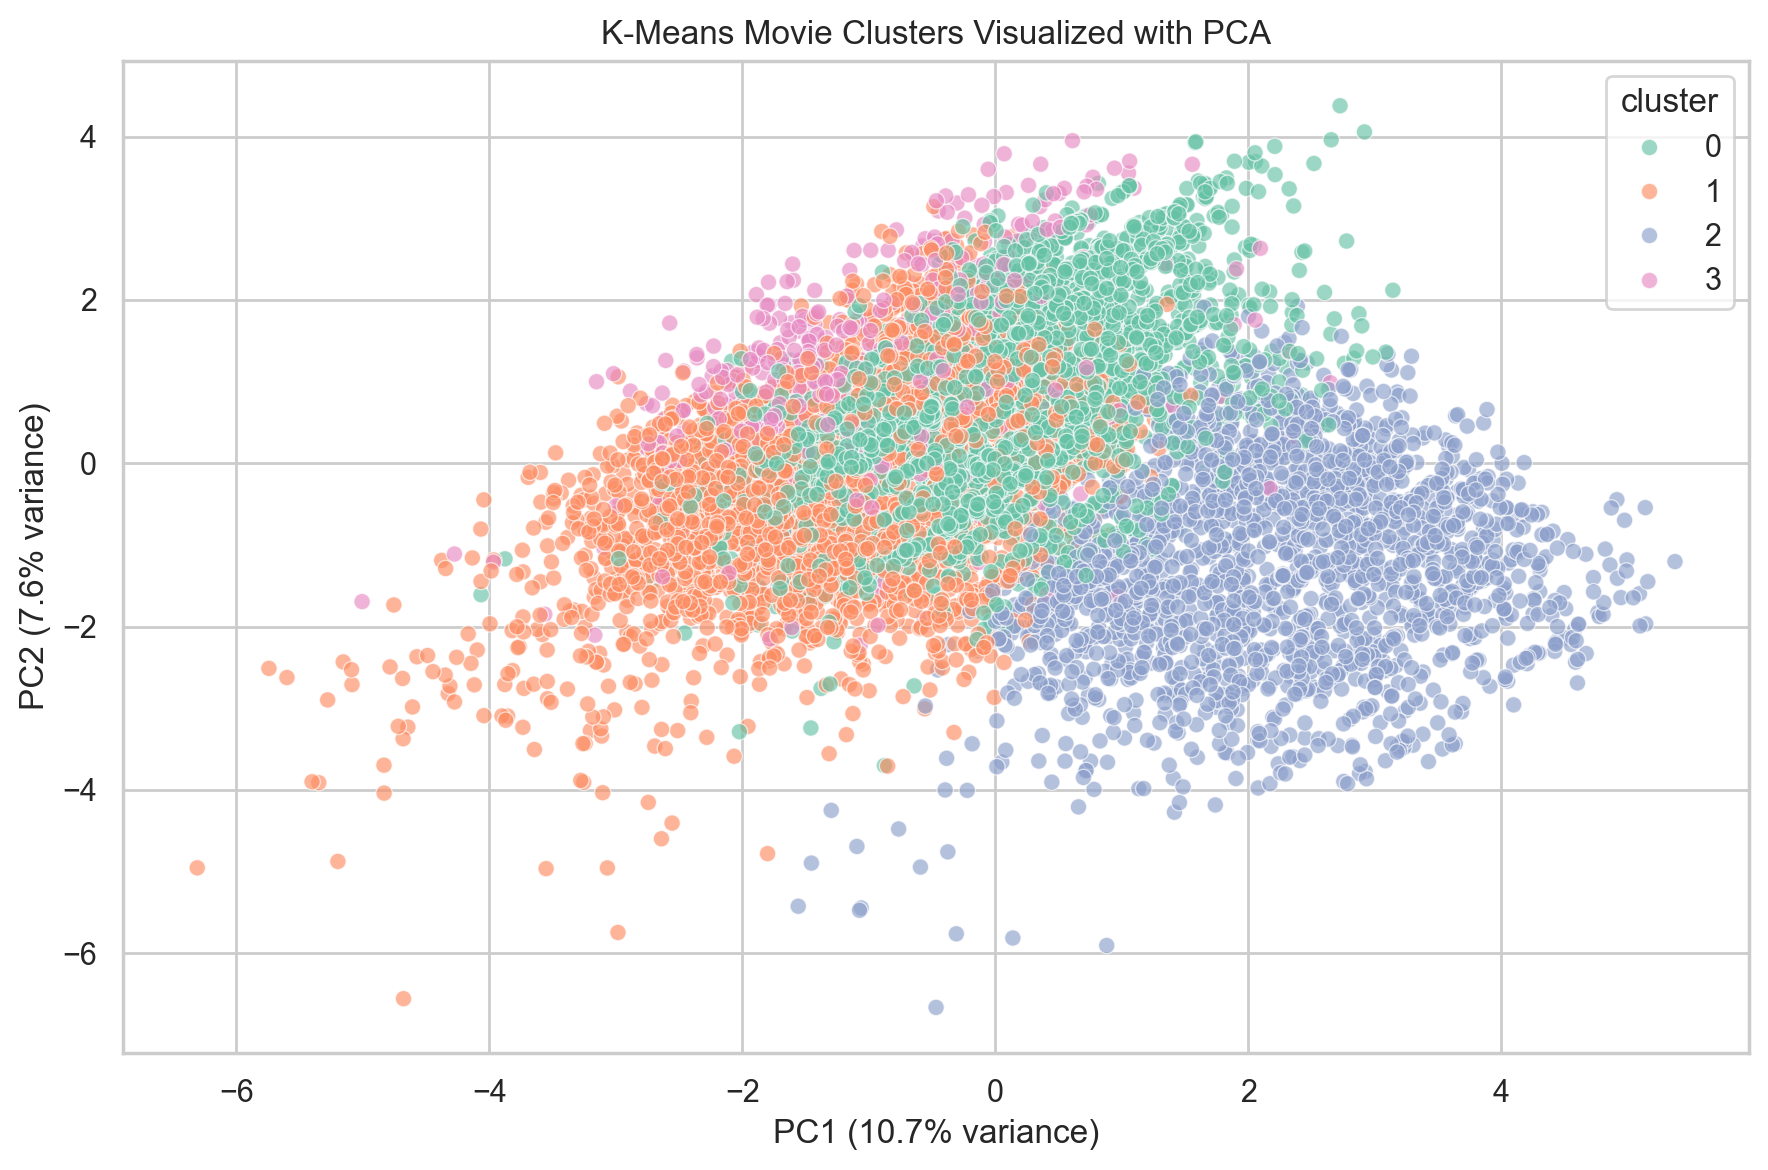

### Cluster profiles

,cluster,movie_count,avg_score,median_budget,median_revenue,median_profit,median_roi,median_year,top_genre,top_language,top_country
0,0,3495,64.464,61000000.0,245144417.0,160485601.0,3.108,2014.0,Drama,English,AU
1,1,3610,63.082,24000000.0,50955490.7,29873431.0,1.659,2012.0,Action,English,AU
2,2,2270,66.999,88000000.0,328151027.7,221522503.2,2.679,2012.0,Animation,English,AU
3,3,592,69.524,39590000.0,79134985.0,42550561.0,1.717,2011.0,Drama,English,AU


In [47]:
fpa.plot_kmeans_elbow(df)
cluster_profile = fpa.clustering_and_pca(df)

display(Markdown("### K-Means elbow plot"))
show_figure("kmeans_elbow_method.png")

display(Markdown("### PCA visualization of clusters"))
show_figure("pca_kmeans_clusters.png")

display(Markdown("### Cluster profiles"))
display(cluster_profile)

## 8. Save final result tables

This runs the same final saving functions as the Python script, producing:
- `model_results.csv`
- `regression_results.csv`
- `classification_results.csv`
- `project_summary.md`

In [48]:
results = [
    mean_baseline,
    baseline,
    improved,
    classification_baseline,
    classification,
]

fpa.save_results(results)
fpa.write_summary(df, results, cluster_profile)

display(Markdown("### Combined model results"))
show_csv("model_results.csv")

display(Markdown("### Regression-only results"))
show_csv("regression_results.csv")

display(Markdown("### Classification-only results"))
show_csv("classification_results.csv")

### Combined model results

,model,rmse,mae,r2,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,low_rate,medium_rate,high_rate
0,Mean score baseline,10.329464,7.717587,-0.000517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Baseline linear regression,10.121755,7.547621,0.039316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Improved linear regression,8.949143,6.546600,0.249014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Majority class baseline: score category,NaN,NaN,NaN,0.367603,0.333333,0.122534,0.333333,0.179196,0.135132,0.367603,0.197619,0.367713,0.301696,0.330591
4,Logistic regression classification: score quan...,NaN,NaN,NaN,0.524574,0.515569,0.508260,0.515569,0.510077,0.514072,0.524574,0.517586,0.367713,0.301696,0.330591


### Regression-only results

,model,rmse,mae,r2,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,low_rate,medium_rate,high_rate
0,Mean score baseline,10.329464,7.717587,-0.000517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Baseline linear regression,10.121755,7.547621,0.039316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Improved linear regression,8.949143,6.546600,0.249014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Classification-only results

,model,rmse,mae,r2,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,low_rate,medium_rate,high_rate
0,Majority class baseline: score category,NaN,NaN,NaN,0.367603,0.333333,0.122534,0.333333,0.179196,0.135132,0.367603,0.197619,0.367713,0.301696,0.330591
1,Logistic regression classification: score quan...,NaN,NaN,NaN,0.524574,0.515569,0.508260,0.515569,0.510077,0.514072,0.524574,0.517586,0.367713,0.301696,0.330591


,model,rmse,mae,r2,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,low_rate,medium_rate,high_rate
0,Majority class baseline: score category,NaN,NaN,NaN,0.367603,0.333333,0.122534,0.333333,0.179196,0.135132,0.367603,0.197619,0.367713,0.301696,0.330591
1,Logistic regression classification: score quan...,NaN,NaN,NaN,0.524574,0.515569,0.508260,0.515569,0.510077,0.514072,0.524574,0.517586,0.367713,0.301696,0.330591


## 9. Main takeaways

Use this section as a starting point for the report/slides.

- The improved regression model performs better than the mean baseline and the simple financial baseline.
- The model still only explains part of the variation in movie scores, which makes sense because movie ratings are subjective.
- The classification model performs better than the majority-class baseline.
- The confusion matrix helps show where the classifier struggles.
- The clustering/PCA section gives an exploratory view of movie groups based on metadata and financial features.